# 01 — Data Load & Merge (v2: expanded feature set)

**Data source:** [IEEE-CIS Fraud Detection](https://www.kaggle.com/c/ieee-fraud-detection) — Kaggle competition dataset (Vesta Corporation), card-not-present online payment transactions. Raw CSVs are **not committed** — download from Kaggle into `data/raw/`.

**v2 change:** keeps ~50 modeling columns (C/D/M features, card/address, email domains, device) instead of 7 core columns, and drops the blanket `dropna()` — XGBoost handles NaN natively and missingness is informative.

**Time note:** `TransactionDT` is a relative timedelta in seconds from an unstated reference date. Dates render as 1970 — cosmetic only; relative windows stay valid.

In [1]:
# CELL 1 - Load raw IEEE-CIS files + match-rate sanity check
import pandas as pd

trans = pd.read_csv("../data/raw/train_transaction.csv")
identity = pd.read_csv("../data/raw/train_identity.csv")

print(f"transactions: {trans.shape}")
print(f"identity:     {identity.shape}")

match_rate = trans["TransactionID"].isin(identity["TransactionID"]).mean()
print(f"transactions with identity data: {match_rate:.1%}")  # expect ~24%

transactions: (590540, 394)
identity:     (144233, 41)
transactions with identity data: 24.4%


In [2]:
# CELL 2 - Merge transaction + identity
df = trans.merge(identity, on="TransactionID", how="left")
print(f"merged: {df.shape}")
assert len(df) == len(trans), "Left join changed row count!"

merged: (590540, 434)


In [3]:
# CELL 3 - Convert time + sort chronologically
# TransactionDT is seconds from an UNSTATED reference date (per the
# competition), not a real timestamp. Dates render as 1970 - cosmetic
# only; day boundaries still align every 86,400 seconds.
df["TransactionDT"] = pd.to_datetime(df["TransactionDT"], unit="s")
df = df.sort_values("TransactionDT").reset_index(drop=True)

In [4]:
# CELL 4 - Synthetic customer ID (with NaN handling)
n_missing = df["card2"].isna().sum()
print(f"card2 missing: {n_missing:,} rows ({n_missing / len(df):.2%}) -> filled with -1")

df["card2"] = df["card2"].fillna(-1)
df["customer_id"] = df["card1"].astype(str) + "_" + df["card2"].astype(str)
print(f"unique synthetic customers: {df['customer_id'].nunique():,}")

card2 missing: 8,933 rows (1.51%) -> filled with -1
unique synthetic customers: 14,524


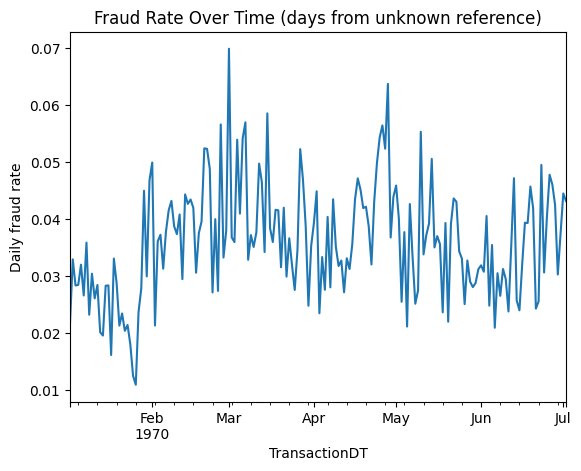

In [5]:
# CELL 5 - First fraud-over-time check
import matplotlib.pyplot as plt

ax = (
    df.set_index("TransactionDT")["isFraud"]
      .resample("D").mean()
      .plot(title="Fraud Rate Over Time (days from unknown reference)")
)
ax.set_ylabel("Daily fraud rate")
plt.show()

In [6]:
# CELL 6 - Select modeling columns (~50) - NO dropna
core_cols = [
    # identifiers / time / target
    "TransactionDT", "TransactionAmt", "customer_id", "ProductCD", "isFraud",
    # card + address
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "dist1",
    # email domains
    "P_emaildomain", "R_emaildomain",
    # counting / timedelta / match features
    *[f"C{i}" for i in range(1, 15)],
    *[f"D{i}" for i in range(1, 16)],
    *[f"M{i}" for i in range(1, 10)],
    # identity (only ~24% of rows have these - NaN is informative)
    "DeviceType", "id_31",
]

df_core = df[core_cols].copy()

# Downcast floats: halves memory on 590K rows
float_cols = df_core.select_dtypes("float64").columns
df_core[float_cols] = df_core[float_cols].astype("float32")

print(f"Selected {len(core_cols)} columns x {len(df_core):,} rows (no rows dropped)")

Selected 56 columns x 590,540 rows (no rows dropped)


In [7]:
# CELL 7 - Save base dataset
import os
os.makedirs("../data/processed", exist_ok=True)

df_core.to_csv("../data/processed/base_transactions.csv", index=False)
print(f"Saved base_transactions.csv: {df_core.shape}")
print(f"Overall fraud rate: {df_core['isFraud'].mean():.2%}")  # expect ~3.5%

Saved base_transactions.csv: (590540, 56)
Overall fraud rate: 3.50%
